In [17]:
import pandas as  pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [18]:
df = pd.read_csv("16-diabetes.csv")

In [19]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [21]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [22]:
df["Insulin"].value_counts()

Insulin
0      374
105     11
130      9
140      9
120      8
      ... 
178      1
127      1
510      1
16       1
112      1
Name: count, Length: 186, dtype: int64

In [23]:
df["BloodPressure"].value_counts()

BloodPressure
70     57
74     52
78     45
68     45
72     44
64     43
80     40
76     39
60     37
0      35
62     34
66     30
82     30
88     25
84     23
90     22
86     21
58     21
50     13
56     12
54     11
52     11
92      8
75      8
65      7
85      6
94      6
48      5
44      4
96      4
110     3
106     3
100     3
98      3
30      2
46      2
55      2
104     2
108     2
40      1
122     1
95      1
102     1
61      1
24      1
38      1
114     1
Name: count, dtype: int64

In [24]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [25]:
columns_to_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in columns_to_check:
    zer0_count = (df[col] == 0) .sum()
    print(zer0_count)

5
35
227
374
11


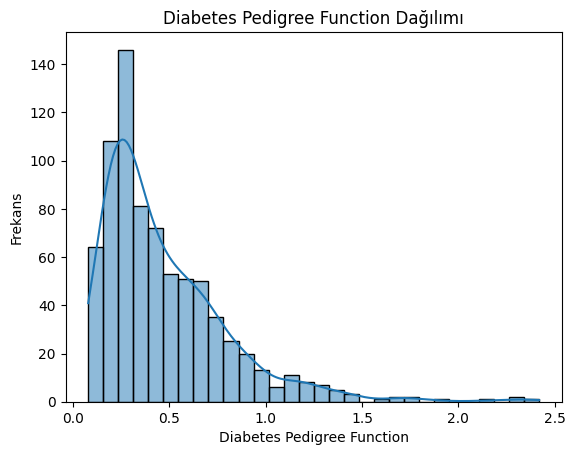

In [26]:
sns.histplot(df["DiabetesPedigreeFunction"], bins=30, kde=True)
plt.title("Diabetes Pedigree Function Dağılımı")
plt.xlabel("Diabetes Pedigree Function")
plt.ylabel("Frekans")
plt.show()

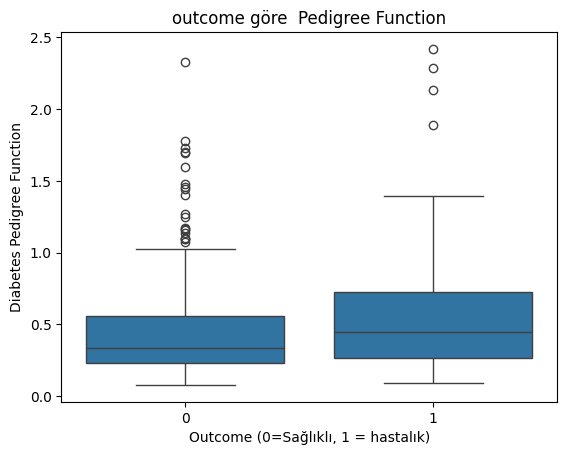

In [27]:
sns.boxplot(x = "Outcome" , y = "DiabetesPedigreeFunction", data = df)
plt.title("outcome göre  Pedigree Function")
plt.xlabel("Outcome (0=Sağlıklı, 1 = hastalık)")
plt.ylabel("Diabetes Pedigree Function")
plt.show()

In [28]:
columns_to_fill = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_filtered = df[(df[columns_to_check] != 0).all(axis=1)]
X = df_filtered.drop("Outcome", axis=1)
y = df_filtered["Outcome"]

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [30]:
X_train.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000
mean,3.456869,122.923323,70.511182,29.268371,156.651757,33.109585,0.531572,31.351438
std,3.308724,30.327072,12.823532,10.358859,116.835533,7.066790,0.343240,10.642703
min,0.000000,56.000000,24.000000,7.000000,14.000000,19.400000,0.085000,21.000000
25%,1.000000,100.000000,62.000000,22.000000,83.000000,28.400000,0.283000,24.000000
50%,2.000000,120.000000,72.000000,29.000000,130.000000,33.200000,0.452000,27.000000
75%,5.000000,143.000000,78.000000,37.000000,185.000000,37.100000,0.682000,37.000000
max,17.000000,197.000000,110.000000,63.000000,846.000000,67.100000,2.420000,81.000000


In [31]:
X_test.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,2.683544,121.455696,71.265823,28.658228,153.696203,32.993671,0.489266,28.936709
std,2.724741,33.067839,11.159346,11.174474,127.234324,6.914057,0.354454,7.989323
min,0.000000,74.000000,50.000000,10.000000,16.000000,18.200000,0.088000,21.000000
25%,1.000000,98.500000,64.000000,19.000000,65.500000,28.100000,0.251000,22.000000
50%,2.000000,109.000000,70.000000,28.000000,115.000000,33.300000,0.365000,27.000000
75%,4.000000,143.500000,78.000000,36.500000,200.000000,36.900000,0.691000,32.500000
max,13.000000,198.000000,106.000000,52.000000,744.000000,49.700000,2.329000,57.000000


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
from sklearn.ensemble  import AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [34]:
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

In [35]:
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.85      0.91      0.88        56
           1       0.74      0.61      0.67        23

    accuracy                           0.82        79
   macro avg       0.79      0.76      0.77        79
weighted avg       0.82      0.82      0.82        79

0.8227848101265823
[[51  5]
 [ 9 14]]


In [36]:
from sklearn.model_selection import GridSearchCV

In [37]:
adabosst_param = {
    "n_estimators": [50,70, 100, 120, 150, 200],
    "learning_rate": [0.001, 0.01, 0.1, 1, 10]
}

In [38]:
grid = GridSearchCV(estimator=AdaBoostClassifier(), param_grid=adabosst_param, cv = 5, verbose= 1,n_jobs = -1 )

In [39]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.001, 0.01, ...], 'n_estimators': [50, 70, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 :

In [40]:
grid.best_params_

{'learning_rate': 1, 'n_estimators': 70}

In [41]:
ada = AdaBoostClassifier(learning_rate=1, n_estimators=150)

In [42]:
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.93      0.88        56
           1       0.76      0.57      0.65        23

    accuracy                           0.82        79
   macro avg       0.80      0.75      0.77        79
weighted avg       0.82      0.82      0.81        79

0.8227848101265823
[[52  4]
 [10 13]]


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [46]:
models = {
    "Logistic Regression": LogisticRegression(random_state = 15),
    "Support Vector Classifier": SVC(random_state = 15),
    "Naive Bayes": GaussianNB()
}

In [48]:
for model_name, model in models.items():
    print(f"model: {model_name} ")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(classification_report(y_test, y_pred))
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Doğruluk Skoru: {accuracy:.4f}\n")
    
    print(confusion_matrix(y_test, y_pred))


model: Logistic Regression 
              precision    recall  f1-score   support

           0       0.81      0.89      0.85        56
           1       0.65      0.48      0.55        23

    accuracy                           0.77        79
   macro avg       0.73      0.69      0.70        79
weighted avg       0.76      0.77      0.76        79

Doğruluk Skoru: 0.7722

[[50  6]
 [12 11]]
model: Support Vector Classifier 
              precision    recall  f1-score   support

           0       0.83      0.86      0.84        56
           1       0.62      0.57      0.59        23

    accuracy                           0.77        79
   macro avg       0.72      0.71      0.72        79
weighted avg       0.77      0.77      0.77        79

Doğruluk Skoru: 0.7722

[[48  8]
 [10 13]]
model: Naive Bayes 
              precision    recall  f1-score   support

           0       0.84      0.88      0.86        56
           1       0.67      0.61      0.64        23

    accuracy  

In [49]:
model_names = ["AdaBoost", "Naive Bayes", "Logistic Regression", "SVC"]
accuracies = [0.82, 0.79, 0.77, 0.77]

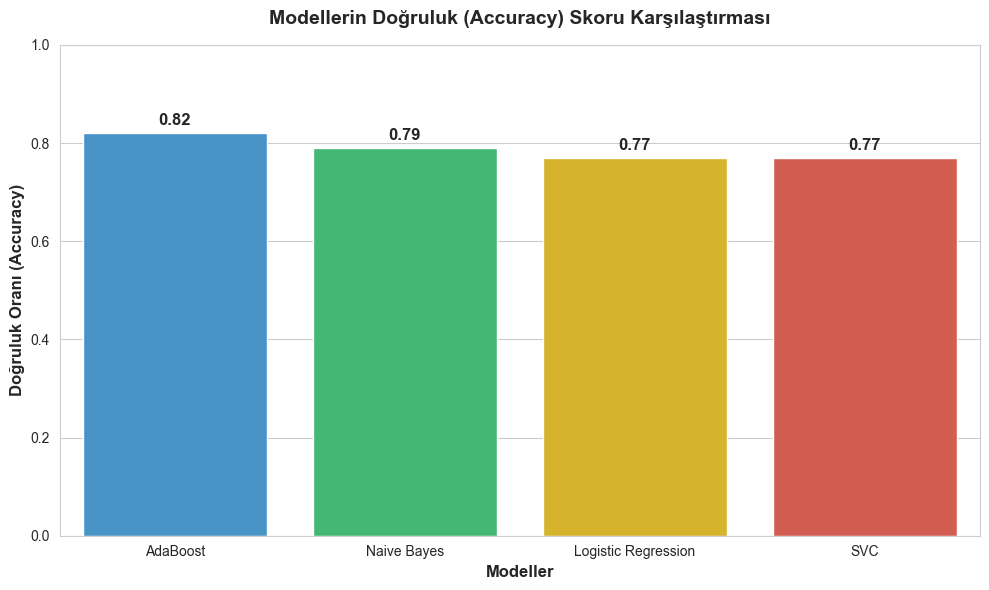

In [52]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
colors = ["#3498db", "#2ecc71", "#f1c40f", "#e74c3c"]
barplot = sns.barplot(x=model_names, y=accuracies, palette=colors, hue=model_names, legend=False)
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=12, fontweight='bold')
plt.title("Modellerin Doğruluk (Accuracy) Skoru Karşılaştırması", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Modeller", fontsize=12, fontweight='bold')
plt.ylabel("Doğruluk Oranı (Accuracy)", fontsize=12, fontweight='bold')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()